# Module 05: Differential Expression Analysis

## Biological Question
What genes are differentially expressed between aging/disease states and senescence states, and how do these patterns differ across cell types?

## Rationale
Pseudobulk DEG analysis aggregates cells per donor to account for biological replicates, providing robust statistical inference while controlling for confounders like sex and cohort.

## Method
- Pseudobulk aggregation: Donor × Senescence_State
- DESeq2 via Seurat FindMarkers
- Covariates: Sex + Cohort
- Thresholds: FDR < 0.05, |log₂FC| > 0.5

## Comparisons (6 per cell type)
**General:**
1. Old vs Young (all cells) — or Disease vs Control
2. SnC vs Non-SnC (all cells)

**Stratified:**
3. Old vs Young (SnC only)
4. Old vs Young (Non-SnC only)
5. SnC vs Non-SnC (Old only)
6. SnC vs Non-SnC (Young only)

## Workflow
Per Cell Type: 05A → 05B → 05C
After all cell types: 05D (Visualization) → 05E (Export)

## 05D Visualization
1. Volcano plots
2. Summary barplots
3. SnC vs Non-SnC scatter
4. 3-way Venn (All vs SnC vs Non-SnC)
5. 2-way Venn (SnC vs Non-SnC)
6. Cross cell type UpSet
7. Heatmaps
8. SenePy overlap (circularity check + novel DEGs)

## Cell Types
Microglia, Astrocyte, OPC

In [1]:
# ════════════════════════════════════════════════════════════════════════════════
# 05A-1: LIBRARIES
# ════════════════════════════════════════════════════════════════════════════════

suppressPackageStartupMessages({
    library(Seurat)
    library(DESeq2)
    library(dplyr)
    library(tidyr)
    library(tibble)
    library(ggplot2)
    library(qs)
})

cat("✓ Libraries loaded\n")

Warning message:
“package ‘Seurat’ was built under R version 4.3.3”
Warning message:
“package ‘sp’ was built under R version 4.3.3”
Warning message:
“package ‘DESeq2’ was built under R version 4.3.3”
Warning message:
“package ‘S4Vectors’ was built under R version 4.3.3”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.3.2”
Warning message:
“package ‘IRanges’ was built under R version 4.3.3”
Warning message:
“package ‘GenomicRanges’ was built under R version 4.3.3”
Warning message:
“package ‘GenomeInfoDb’ was built under R version 4.3.2”
Warning message:
“package ‘SummarizedExperiment’ was built under R version 4.3.2”
Warning message:
“package ‘MatrixGenerics’ was built under R version 4.3.3”
Warning message:
“package ‘matrixStats’ was built under R version 4.3.3”
Warning message:
“package ‘Biobase’ was built under R version 4.3.3”
Warning message:
“package ‘dplyr’ was built under R version 4.3.3”
Warning message:
“package ‘tidyr’ was built under R version 4.3.3”
War

✓ Libraries loaded


In [2]:
# ════════════════════════════════════════════════════════════════════════════════
# 05A-2: CONFIGURATION
# ════════════════════════════════════════════════════════════════════════════════

DATASET <- "psychad_aging"
CELL_TYPE <- "Microglia"  # Options: 'Microglia', 'Astrocyte', 'OPC'

BASE_DIR <- "/fs/scratch/PAS2598/senescence_analysis"

# Paths
INPUT_FILE <- file.path(BASE_DIR, "data", "04_subclustered", DATASET, 
                         paste0(DATASET, "_subclustered.qs"))
RESULTS_DIR <- file.path(BASE_DIR, "results", "05_deg", DATASET, tolower(CELL_TYPE))
FIGURES_DIR <- file.path(BASE_DIR, "figures", "05_deg", DATASET, tolower(CELL_TYPE))

dir.create(RESULTS_DIR, recursive = TRUE, showWarnings = FALSE)
dir.create(FIGURES_DIR, recursive = TRUE, showWarnings = FALSE)

# Thresholds
FDR_THRESHOLD <- 0.05
LFC_THRESHOLD <- 0.5
MIN_CELLS_PER_SAMPLE <- 10
MIN_COUNTS_PER_GENE <- 10
MIN_SAMPLES_PER_GENE <- 3

cat("Configuration:\n")
cat("  Dataset:", DATASET, "\n")
cat("  Cell type:", CELL_TYPE, "\n")
cat("  Input:", INPUT_FILE, "\n")

Configuration:
  Dataset: psychad_aging 
  Cell type: Microglia 
  Input: /fs/scratch/PAS2598/senescence_analysis/data/04_subclustered/psychad_aging/psychad_aging_subclustered.qs 


In [3]:
# ════════════════════════════════════════════════════════════════════════════════
# 05A-3: DATASET-SPECIFIC COLUMN MAPPINGS
# ════════════════════════════════════════════════════════════════════════════════

DATASET_CONFIG <- list(
    "psychad_aging" = list(
        cell_type_col = "subclass",
        donor_col = "Sample",
        study_group_col = "Study_Group",
        sex_col = "Sex",
        cohort_col = "Cohort",
        senescence_col = "senescence_label",
        young_groups = c("Age_20_29", "Age_30_39"),
        old_groups = c("Age_70_79", "Age_80_100"),
        analysis_type = "aging"
    ),
    "psychad_ad" = list(
        cell_type_col = "subclass",
        donor_col = "Sample",
        study_group_col = "Study_Group",
        sex_col = "Sex",
        cohort_col = "Cohort",
        senescence_col = "senescence_label",
        control_groups = c("Control"),
        disease_groups = c("AD"),
        analysis_type = "disease"
    ),
    "psychencode" = list(
        cell_type_col = "cell_type",
        donor_col = "sample_id",
        study_group_col = "Study_Group",
        sex_col = "Biological_Sex",
        cohort_col = "Batch",
        senescence_col = "senescence_label",
        young_groups = c("Age_20_29", "Age_30_39"),
        old_groups = c("Age_70_79", "Age_80_100"),
        analysis_type = "aging"
    ),
    "mathys" = list(
        cell_type_col = "broad.cell.type",
        donor_col = "Subject",
        study_group_col = "Diagnosis",
        sex_col = "Sex",
        cohort_col = NULL,
        senescence_col = "senescence_label",
        control_groups = c("Control"),
        disease_groups = c("AD"),
        analysis_type = "disease"
    )
)

# Extract config
config <- DATASET_CONFIG[[DATASET]]

CELL_TYPE_COL <- config$cell_type_col
DONOR_COL <- config$donor_col
STUDY_GROUP_COL <- config$study_group_col
SEX_COL <- config$sex_col
COHORT_COL <- config$cohort_col
SENESCENCE_COL <- config$senescence_col
ANALYSIS_TYPE <- config$analysis_type

if (ANALYSIS_TYPE == "aging") {
    YOUNG_GROUPS <- config$young_groups
    OLD_GROUPS <- config$old_groups
} else {
    CONTROL_GROUPS <- config$control_groups
    DISEASE_GROUPS <- config$disease_groups
}

cat("Column mappings:\n")
cat("  Cell type:", CELL_TYPE_COL, "\n")
cat("  Donor:", DONOR_COL, "\n")
cat("  Senescence:", SENESCENCE_COL, "\n")
cat("  Analysis type:", ANALYSIS_TYPE, "\n")

Column mappings:
  Cell type: subclass 
  Donor: Sample 
  Senescence: senescence_label 
  Analysis type: aging 


In [4]:
# ════════════════════════════════════════════════════════════════════════════════
# 05A-4: LOAD DATA
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("LOADING DATA\n")
cat("================================================================================\n")

seurat <- qread(INPUT_FILE)
cat("\n✓ Loaded:", ncol(seurat), "cells ×", nrow(seurat), "genes\n")

cat("\nCell types available:\n")
print(table(seurat[[CELL_TYPE_COL, drop = TRUE]]))


LOADING DATA

✓ Loaded: 122192 cells × 34890 genes

Cell types available:

Astrocyte Microglia       OPC 
    63658     22475     36059 


In [5]:
# ════════════════════════════════════════════════════════════════════════════════
# 05A-5: SUBSET TO CELL TYPE
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("SUBSETTING TO", CELL_TYPE, "\n")
cat("================================================================================\n")

seurat_ct <- subset(seurat, cells = colnames(seurat)[seurat[[CELL_TYPE_COL, drop = TRUE]] == CELL_TYPE])
cat("\n✓", CELL_TYPE, "cells:", ncol(seurat_ct), "\n")

# Clean up
rm(seurat)
gc(verbose = FALSE)


SUBSETTING TO Microglia 

✓ Microglia cells: 22475 


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,8117179,433.6,14348234,766.3,14348234,766.3
Vcells,949326555,7242.8,8245145538,62905.5,7159126944,54619.9


In [6]:
# ════════════════════════════════════════════════════════════════════════════════
# 05A-6: ASSIGN GROUPS
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("ASSIGNING GROUPS\n")
cat("================================================================================\n")

if (ANALYSIS_TYPE == "aging") {
    seurat_ct$Age_Group <- "Middle"
    seurat_ct$Age_Group[seurat_ct[[STUDY_GROUP_COL, drop = TRUE]] %in% YOUNG_GROUPS] <- "Young"
    seurat_ct$Age_Group[seurat_ct[[STUDY_GROUP_COL, drop = TRUE]] %in% OLD_GROUPS] <- "Old"
    
    GROUP_COL <- "Age_Group"
    COMPARISON_GROUPS <- c("Young", "Old")
    
    cat("\nAge group distribution:\n")
    print(table(seurat_ct$Age_Group))
    
} else {
    seurat_ct$Condition <- "Other"
    seurat_ct$Condition[seurat_ct[[STUDY_GROUP_COL, drop = TRUE]] %in% CONTROL_GROUPS] <- "Control"
    seurat_ct$Condition[seurat_ct[[STUDY_GROUP_COL, drop = TRUE]] %in% DISEASE_GROUPS] <- "Disease"
    
    GROUP_COL <- "Condition"
    COMPARISON_GROUPS <- c("Control", "Disease")
    
    cat("\nCondition distribution:\n")
    print(table(seurat_ct$Condition))
}


ASSIGNING GROUPS

Age group distribution:

Middle    Old  Young 
  9736   5839   6900 


In [7]:
# ════════════════════════════════════════════════════════════════════════════════
# 05A-7: CHECK DISTRIBUTIONS
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("CHECK DISTRIBUTIONS\n")
cat("================================================================================\n")

cat("\nSenescence distribution:\n")
print(table(seurat_ct[[SENESCENCE_COL, drop = TRUE]]))

cat("\nGroup × Senescence:\n")
print(table(seurat_ct[[GROUP_COL, drop = TRUE]], seurat_ct[[SENESCENCE_COL, drop = TRUE]]))

cat("\nSex distribution:\n")
print(table(seurat_ct[[SEX_COL, drop = TRUE]]))

# Check cohort
if (!is.null(COHORT_COL) && COHORT_COL %in% colnames(seurat_ct@meta.data)) {
    cat("\nCohort distribution:\n")
    print(table(seurat_ct[[COHORT_COL, drop = TRUE]]))
    HAS_COHORT <- TRUE
} else {
    HAS_COHORT <- FALSE
    cat("\nNo Cohort column\n")
}

cat("\n================================================================================\n")
cat("05A COMPLETE\n")
cat("================================================================================\n")


CHECK DISTRIBUTIONS

Senescence distribution:

Non-SnC     SnC 
  20242    2233 

Group × Senescence:
        
         Non-SnC  SnC
  Middle    8630 1106
  Old       5017  822
  Young     6595  305

Sex distribution:

Female   Male 
 10668  11807 

Cohort distribution:

               HBCC Mt Sinai Brain Bank 
              13049                9426 

05A COMPLETE


In [8]:
# ════════════════════════════════════════════════════════════════════════════════
# 05B: PSEUDOBULK AGGREGATION
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05B: PSEUDOBULK AGGREGATION\n")
cat("================================================================================\n")

# ────────────────────────────────────────────────────────────────────────────────
# RELOAD DATA FRESH
# ────────────────────────────────────────────────────────────────────────────────

seurat <- qread(INPUT_FILE)
seurat_ct <- subset(seurat, cells = colnames(seurat)[seurat[[CELL_TYPE_COL, drop = TRUE]] == CELL_TYPE])
rm(seurat)
gc(verbose = FALSE)

cat("✓ Loaded:", ncol(seurat_ct), CELL_TYPE, "cells\n")

# ────────────────────────────────────────────────────────────────────────────────
# ASSIGN AGE GROUPS
# ────────────────────────────────────────────────────────────────────────────────

if (ANALYSIS_TYPE == "aging") {
    seurat_ct$Age_Group <- "Middle"
    seurat_ct$Age_Group[seurat_ct[[STUDY_GROUP_COL, drop = TRUE]] %in% YOUNG_GROUPS] <- "Young"
    seurat_ct$Age_Group[seurat_ct[[STUDY_GROUP_COL, drop = TRUE]] %in% OLD_GROUPS] <- "Old"
    GROUP_COL <- "Age_Group"
} else {
    seurat_ct$Condition <- "Other"
    seurat_ct$Condition[seurat_ct[[STUDY_GROUP_COL, drop = TRUE]] %in% CONTROL_GROUPS] <- "Control"
    seurat_ct$Condition[seurat_ct[[STUDY_GROUP_COL, drop = TRUE]] %in% DISEASE_GROUPS] <- "Disease"
    GROUP_COL <- "Condition"
}

cat("\nGroup distribution:\n")
print(table(seurat_ct[[GROUP_COL, drop = TRUE]]))

cat("\nSenescence distribution:\n")
print(table(seurat_ct[[SENESCENCE_COL, drop = TRUE]]))

# ────────────────────────────────────────────────────────────────────────────────
# AGGREGATE EXPRESSION (return Seurat object)
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- Aggregating Expression ---\n")

# Build group.by vector based on available columns
group_by_cols <- c(DONOR_COL, GROUP_COL, SENESCENCE_COL, SEX_COL)
if (HAS_COHORT) {
    group_by_cols <- c(group_by_cols, COHORT_COL)
}

cat("Grouping by:", paste(group_by_cols, collapse = ", "), "\n")

pseudo <- AggregateExpression(
    seurat_ct,
    assays = "RNA",
    return.seurat = TRUE,
    group.by = group_by_cols
)

cat("\n✓ Pseudobulk Seurat:", ncol(pseudo), "samples\n")

# Check sample names
cat("\nSample names (first 5):\n")
print(head(Cells(pseudo), 5))

# ────────────────────────────────────────────────────────────────────────────────
# CREATE COMPOSITE IDENTITY COLUMNS
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- Creating Identity Columns ---\n")

# Extract metadata from column names (they are concatenated with _)
# Format: Donor_Group_Senescence_Sex_Cohort

pseudo$Group_SnC <- paste0(pseudo[[GROUP_COL, drop = TRUE]], "_", 
                           pseudo[[SENESCENCE_COL, drop = TRUE]])

cat("\nGroup_SnC distribution:\n")
print(table(pseudo$Group_SnC))

# ────────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ────────────────────────────────────────────────────────────────────────────────

cat("\n================================================================================\n")
cat("PSEUDOBULK SUMMARY\n")
cat("================================================================================\n")

cat("\nTotal pseudobulk samples:", ncol(pseudo), "\n")

cat("\nSamples per Group × Senescence:\n")
print(table(pseudo[[GROUP_COL, drop = TRUE]], pseudo[[SENESCENCE_COL, drop = TRUE]]))

if (HAS_COHORT) {
    cat("\nSamples per Cohort:\n")
    print(table(pseudo[[COHORT_COL, drop = TRUE]]))
}

cat("\nSamples per Sex:\n")
print(table(pseudo[[SEX_COL, drop = TRUE]]))

cat("\n================================================================================\n")
cat("05B COMPLETE\n")
cat("================================================================================\n")


05B: PSEUDOBULK AGGREGATION


,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,8125443,434,14348234,766.3,14348234,766.3
Vcells,949345361,7243,7915403716,60389.8,8093889618,61751.5


✓ Loaded: 22475 Microglia cells

Group distribution:

Middle    Old  Young 
  9736   5839   6900 

Senescence distribution:

Non-SnC     SnC 
  20242    2233 

--- Aggregating Expression ---
Grouping by: Sample, Age_Group, senescence_label, Sex, Cohort 


Names of identity class contain underscores ('_'), replacing with dashes ('-')
This message is displayed once every 8 hours.
Centering and scaling data matrix




✓ Pseudobulk Seurat: 227 samples

Sample names (first 5):
[1] "AMPAD-HBCC-0000000004_Middle_Non-SnC_Female_HBCC"
[2] "AMPAD-HBCC-0000000006_Old_Non-SnC_Male_HBCC"     
[3] "AMPAD-HBCC-0000000008_Young_Non-SnC_Male_HBCC"   
[4] "AMPAD-HBCC-0000000008_Young_SnC_Male_HBCC"       
[5] "AMPAD-HBCC-0000000010_Young_Non-SnC_Male_HBCC"   

--- Creating Identity Columns ---

Group_SnC distribution:

Middle_Non-SnC     Middle_SnC    Old_Non-SnC        Old_SnC  Young_Non-SnC 
            56             47             38             35             30 
     Young_SnC 
            21 

PSEUDOBULK SUMMARY

Total pseudobulk samples: 227 

Samples per Group × Senescence:
        
         Non-SnC SnC
  Middle      56  47
  Old         38  35
  Young       30  21

Samples per Cohort:

               HBCC Mt Sinai Brain Bank 
                105                 122 

Samples per Sex:

Female   Male 
   115    112 

05B COMPLETE


In [9]:
# ════════════════════════════════════════════════════════════════════════════════
# 05C: DEG ANALYSIS
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05C: DEG ANALYSIS\n")
cat("================================================================================\n")

# Set identity for comparisons
Idents(pseudo) <- "Group_SnC"
cat("\nIdentities set to: Group_SnC\n")
print(table(Idents(pseudo)))

# Build latent.vars
latent_vars <- c(SEX_COL)
if (HAS_COHORT) {
    latent_vars <- c(latent_vars, COHORT_COL)
}
cat("\nCovariates (latent.vars):", paste(latent_vars, collapse = ", "), "\n")

# ────────────────────────────────────────────────────────────────────────────────
# DEFINE COMPARISONS
# ────────────────────────────────────────────────────────────────────────────────

if (ANALYSIS_TYPE == "aging") {
    comparisons <- list(
        # General
        OldvsYoung_all = list(ident.1 = c("Old_SnC", "Old_Non-SnC"), 
                               ident.2 = c("Young_SnC", "Young_Non-SnC"),
                               name = "OldvsYoung_all"),
        SnCvsNonSnC_all = list(ident.1 = c("Young_SnC", "Middle_SnC", "Old_SnC"), 
                                ident.2 = c("Young_Non-SnC", "Middle_Non-SnC", "Old_Non-SnC"),
                                name = "SnCvsNonSnC_all"),
        # Stratified
        OldvsYoung_SnC = list(ident.1 = "Old_SnC", 
                               ident.2 = "Young_SnC",
                               name = "OldvsYoung_SnC"),
        OldvsYoung_NonSnC = list(ident.1 = "Old_Non-SnC", 
                                  ident.2 = "Young_Non-SnC",
                                  name = "OldvsYoung_NonSnC"),
        SnCvsNonSnC_Old = list(ident.1 = "Old_SnC", 
                                ident.2 = "Old_Non-SnC",
                                name = "SnCvsNonSnC_Old"),
        SnCvsNonSnC_Young = list(ident.1 = "Young_SnC", 
                                  ident.2 = "Young_Non-SnC",
                                  name = "SnCvsNonSnC_Young")
    )
} else {
    comparisons <- list(
        # General
        DiseasevsControl_all = list(ident.1 = c("Disease_SnC", "Disease_Non-SnC"), 
                                     ident.2 = c("Control_SnC", "Control_Non-SnC"),
                                     name = "DiseasevsControl_all"),
        SnCvsNonSnC_all = list(ident.1 = c("Control_SnC", "Disease_SnC"), 
                                ident.2 = c("Control_Non-SnC", "Disease_Non-SnC"),
                                name = "SnCvsNonSnC_all"),
        # Stratified
        DiseasevsControl_SnC = list(ident.1 = "Disease_SnC", 
                                     ident.2 = "Control_SnC",
                                     name = "DiseasevsControl_SnC"),
        DiseasevsControl_NonSnC = list(ident.1 = "Disease_Non-SnC", 
                                        ident.2 = "Control_Non-SnC",
                                        name = "DiseasevsControl_NonSnC"),
        SnCvsNonSnC_Disease = list(ident.1 = "Disease_SnC", 
                                    ident.2 = "Disease_Non-SnC",
                                    name = "SnCvsNonSnC_Disease"),
        SnCvsNonSnC_Control = list(ident.1 = "Control_SnC", 
                                    ident.2 = "Control_Non-SnC",
                                    name = "SnCvsNonSnC_Control")
    )
}

cat("\nComparisons defined:", length(comparisons), "\n")
for (comp in names(comparisons)) {
    cat("  •", comp, "\n")
}

# ────────────────────────────────────────────────────────────────────────────────
# RUN DEG ANALYSIS
# ────────────────────────────────────────────────────────────────────────────────

results_list <- list()
summary_list <- list()

for (comp_name in names(comparisons)) {
    comp <- comparisons[[comp_name]]
    
    cat("\n────────────────────────────────────────────────────────────────────────────\n")
    cat("COMPARISON:", comp$name, "\n")
    cat("────────────────────────────────────────────────────────────────────────────\n")
    
    cat("  ident.1:", paste(comp$ident.1, collapse = ", "), "\n")
    cat("  ident.2:", paste(comp$ident.2, collapse = ", "), "\n")
    
    # Check if groups exist
    available_groups <- unique(Idents(pseudo))
    ident1_exists <- all(comp$ident.1 %in% available_groups)
    ident2_exists <- all(comp$ident.2 %in% available_groups)
    
    if (!ident1_exists || !ident2_exists) {
        cat("  ⚠ SKIPPED - groups not found\n")
        next
    }
    
    # Run DESeq2
    tryCatch({
        deg <- FindMarkers(
            object = pseudo,
            ident.1 = comp$ident.1,
            ident.2 = comp$ident.2,
            latent.vars = latent_vars,
            test.use = "DESeq2",
            verbose = FALSE
        )
        
        # Add gene column
        deg$gene <- rownames(deg)
        
        # Add significance
        deg$significant <- deg$p_val_adj < FDR_THRESHOLD & abs(deg$avg_log2FC) > LFC_THRESHOLD
        deg$direction <- ifelse(deg$avg_log2FC > 0, "Up", "Down")
        deg$direction[!deg$significant] <- "NS"
        
        # Summary
        n_up <- sum(deg$direction == "Up", na.rm = TRUE)
        n_down <- sum(deg$direction == "Down", na.rm = TRUE)
        
        cat("  Results: ", n_up, "up, ", n_down, "down (", n_up + n_down, "total)\n")
        
        # Save
        out_file <- file.path(RESULTS_DIR, paste0(DATASET, "_", tolower(CELL_TYPE), "_", comp$name, ".csv"))
        write.csv(deg, out_file, row.names = FALSE)
        cat("  ✓ Saved:", basename(out_file), "\n")
        
        # Store results
        results_list[[comp$name]] <- deg
        summary_list[[comp$name]] <- data.frame(
            Comparison = comp$name,
            Up = n_up,
            Down = n_down,
            Total = n_up + n_down
        )
        
    }, error = function(e) {
        cat("  ✗ ERROR:", conditionMessage(e), "\n")
    })
}

# ────────────────────────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ────────────────────────────────────────────────────────────────────────────────

cat("\n================================================================================\n")
cat("DEG SUMMARY\n")
cat("================================================================================\n")

if (length(summary_list) > 0) {
    summary_df <- do.call(rbind, summary_list)
    print(summary_df)
    
    # Save summary
    summary_file <- file.path(RESULTS_DIR, paste0(DATASET, "_", tolower(CELL_TYPE), "_deg_summary.csv"))
    write.csv(summary_df, summary_file, row.names = FALSE)
    cat("\n✓ Summary saved:", basename(summary_file), "\n")
}

# ────────────────────────────────────────────────────────────────────────────────
# SAVE PSEUDOBULK OBJECT FOR VISUALIZATION
# ────────────────────────────────────────────────────────────────────────────────

pseudo_file <- file.path(RESULTS_DIR, paste0(DATASET, "_", tolower(CELL_TYPE), "_pseudobulk.qs"))
qsave(pseudo, pseudo_file)
cat("✓ Pseudobulk saved:", basename(pseudo_file), "\n")

cat("\n================================================================================\n")
cat("05C COMPLETE\n")
cat("================================================================================\n")


05C: DEG ANALYSIS

Identities set to: Group_SnC

Middle_Non-SnC    Old_Non-SnC  Young_Non-SnC      Young_SnC     Middle_SnC 
            56             38             30             21             47 
       Old_SnC 
            35 

Covariates (latent.vars): Sex, Cohort 

Comparisons defined: 6 
  • OldvsYoung_all 
  • SnCvsNonSnC_all 
  • OldvsYoung_SnC 
  • OldvsYoung_NonSnC 
  • SnCvsNonSnC_Old 
  • SnCvsNonSnC_Young 

────────────────────────────────────────────────────────────────────────────
COMPARISON: OldvsYoung_all 
────────────────────────────────────────────────────────────────────────────
  ident.1: Old_SnC, Old_Non-SnC 
  ident.2: Young_SnC, Young_Non-SnC 


Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“'latent.vars' is only used for the following tests: negbinom, poisson, MAST, LR”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



  Results:  412 up,  183 down ( 595 total)
  ✓ Saved: psychad_aging_microglia_OldvsYoung_all.csv 

────────────────────────────────────────────────────────────────────────────
COMPARISON: SnCvsNonSnC_all 
────────────────────────────────────────────────────────────────────────────
  ident.1: Young_SnC, Middle_SnC, Old_SnC 
  ident.2: Young_Non-SnC, Middle_Non-SnC, Old_Non-SnC 


Warning message:
“'latent.vars' is only used for the following tests: negbinom, poisson, MAST, LR”
converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



  Results:  74 up,  54 down ( 128 total)
  ✓ Saved: psychad_aging_microglia_SnCvsNonSnC_all.csv 

────────────────────────────────────────────────────────────────────────────
COMPARISON: OldvsYoung_SnC 
────────────────────────────────────────────────────────────────────────────
  ident.1: Old_SnC 
  ident.2: Young_SnC 


...

  Results:  301 up,  133 down ( 434 total)
  ✓ Saved: psychad_aging_microglia_OldvsYoung_NonSnC.csv 

────────────────────────────────────────────────────────────────────────────
COMPARISON: SnCvsNonSnC_Old 
────────────────────────────────────────────────────────────────────────────
  ident.1: Old_SnC 
  ident.2: Old_Non-SnC 


Warning message:
“'latent.vars' is only used for the following tests: negbinom, poisson, MAST, LR”
converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



  Results:  15 up,  34 down ( 49 total)
  ✓ Saved: psychad_aging_microglia_SnCvsNonSnC_Old.csv 

────────────────────────────────────────────────────────────────────────────
COMPARISON: SnCvsNonSnC_Young 
────────────────────────────────────────────────────────────────────────────
  ident.1: Young_SnC 
  ident.2: Young_Non-SnC 


Warning message:
“'latent.vars' is only used for the following tests: negbinom, poisson, MAST, LR”
converting counts to integer mode

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates



  Results:  49 up,  20 down ( 69 total)
  ✓ Saved: psychad_aging_microglia_SnCvsNonSnC_Young.csv 

DEG SUMMARY
                         Comparison  Up Down Total
OldvsYoung_all       OldvsYoung_all 412  183   595
SnCvsNonSnC_all     SnCvsNonSnC_all  74   54   128
OldvsYoung_SnC       OldvsYoung_SnC  65   52   117
OldvsYoung_NonSnC OldvsYoung_NonSnC 301  133   434
SnCvsNonSnC_Old     SnCvsNonSnC_Old  15   34    49
SnCvsNonSnC_Young SnCvsNonSnC_Young  49   20    69

✓ Summary saved: psychad_aging_microglia_deg_summary.csv 
✓ Pseudobulk saved: psychad_aging_microglia_pseudobulk.qs 

05C COMPLETE


---

## 05D: Visualization

**Runs after all cell types have completed 05A → 05B → 05C**

**Per Cell Type:**
- Volcano plots (6 comparisons)
- DEG summary barplot
- SnC vs Non-SnC scatter (FC concordance)
- 3-way Venn (All vs SnC vs Non-SnC)
- 2-way Venn (SnC vs Non-SnC)
- Heatmap (top DEGs)

**Cross Cell Type:**
- UpSet plots (upregulated & downregulated)

---

In [10]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-0: SETUP AND LOAD RESULTS
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-0: SETUP AND LOAD RESULTS\n")
cat("================================================================================\n")

suppressPackageStartupMessages({
    library(ggplot2)
    library(ggrepel)
    library(patchwork)
    library(ComplexHeatmap)
    library(circlize)
    library(VennDiagram)
    library(UpSetR)
    library(grid)
    library(dplyr)
    library(tidyr)
    library(RColorBrewer)
})

# ────────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ────────────────────────────────────────────────────────────────────────────────

if (!exists("BASE_DIR")) BASE_DIR <- "/fs/scratch/PAS2598/senescence_analysis"
if (!exists("DATASET")) DATASET <- "psychad_aging"
if (!exists("ANALYSIS_TYPE")) ANALYSIS_TYPE <- "aging"
if (!exists("FDR_THRESHOLD")) FDR_THRESHOLD <- 0.05
if (!exists("LFC_THRESHOLD")) LFC_THRESHOLD <- 0.5

results_base <- file.path(BASE_DIR, "results", "05_deg", DATASET)
figures_base <- file.path(BASE_DIR, "figures", "05_deg", DATASET)

cat("\n--- Configuration ---\n")
cat("BASE_DIR:", BASE_DIR, "\n")
cat("DATASET:", DATASET, "\n")
cat("ANALYSIS_TYPE:", ANALYSIS_TYPE, "\n")
cat("Results:", results_base, "\n")
cat("Figures:", figures_base, "\n")

# ────────────────────────────────────────────────────────────────────────────────
# DISCOVER AVAILABLE CELL TYPES
# ────────────────────────────────────────────────────────────────────────────────

if (!dir.exists(results_base)) {
    stop("ERROR: Results directory not found: ", results_base)
}

available_cell_types <- list.dirs(results_base, recursive = FALSE, full.names = FALSE)

if (length(available_cell_types) == 0) {
    stop("ERROR: No cell type results found. Run 05A-05C first.")
}

cat("\n--- Available Cell Types ---\n")
cat("Found:", paste(available_cell_types, collapse = ", "), "\n")

# ────────────────────────────────────────────────────────────────────────────────
# LOAD ALL RESULTS
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- Loading DEG Results ---\n")

all_results <- list()  # Nested: all_results[[cell_type]][[comparison]]
deg_summary_all <- data.frame()

for (ct in available_cell_types) {
    ct_path <- file.path(results_base, ct)
    csv_files <- list.files(ct_path, pattern = "\\.csv$", full.names = TRUE)
    comp_files <- csv_files[!grepl("summary|gsea|genes", csv_files)]
    
    all_results[[ct]] <- list()
    
    cat("\n ", toupper(ct), "\n")
    
    for (f in comp_files) {
        fname <- basename(f)
        comp_name <- gsub(paste0(DATASET, "_", ct, "_"), "", gsub("\\.csv$", "", fname))
        
        deg_data <- read.csv(f)
        
        # Add columns if missing
        if (!"significant" %in% colnames(deg_data)) {
            deg_data$significant <- deg_data$p_val_adj < FDR_THRESHOLD & 
                                    abs(deg_data$avg_log2FC) > LFC_THRESHOLD
        }
        if (!"direction" %in% colnames(deg_data)) {
            deg_data$direction <- "NS"
            deg_data$direction[deg_data$significant & deg_data$avg_log2FC > 0] <- "Up"
            deg_data$direction[deg_data$significant & deg_data$avg_log2FC < 0] <- "Down"
        }
        
        all_results[[ct]][[comp_name]] <- deg_data
        
        n_up <- sum(deg_data$direction == "Up", na.rm = TRUE)
        n_down <- sum(deg_data$direction == "Down", na.rm = TRUE)
        
        cat(sprintf("    • %s: %d up, %d down\n", comp_name, n_up, n_down))
        
        deg_summary_all <- rbind(deg_summary_all, data.frame(
            cell_type = ct, comparison = comp_name, up = n_up, down = n_down
        ))
    }
}

# ────────────────────────────────────────────────────────────────────────────────
# SUMMARY
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- DEG Summary (All Cell Types) ---\n")
print(deg_summary_all)

cat("\n================================================================================\n")
cat("05D-0 COMPLETE\n")
cat("================================================================================\n")
cat("\n✓ Loaded", length(available_cell_types), "cell types\n")
cat("✓ Results in: all_results[[cell_type]][[comparison]]\n")
cat("✓ Summary in: deg_summary_all\n")


05D-0: SETUP AND LOAD RESULTS


Warning message:
“package ‘ggrepel’ was built under R version 4.3.3”
Warning message:
“package ‘ComplexHeatmap’ was built under R version 4.3.2”
Warning message:
“package ‘circlize’ was built under R version 4.3.3”
Warning message:
“package ‘VennDiagram’ was built under R version 4.3.3”
Warning message:
“package ‘futile.logger’ was built under R version 4.3.3”
Warning message:
“package ‘UpSetR’ was built under R version 4.3.3”
Warning message:
“package ‘RColorBrewer’ was built under R version 4.3.3”



--- Configuration ---
BASE_DIR: /fs/scratch/PAS2598/senescence_analysis 
DATASET: psychad_aging 
ANALYSIS_TYPE: aging 
Results: /fs/scratch/PAS2598/senescence_analysis/results/05_deg/psychad_aging 
Figures: /fs/scratch/PAS2598/senescence_analysis/figures/05_deg/psychad_aging 

--- Available Cell Types ---
Found: astrocyte, microglia, opc 

--- Loading DEG Results ---

  ASTROCYTE 
    • OldvsYoung_all: 336 up, 331 down
    • OldvsYoung_NonSnC: 229 up, 205 down
    • OldvsYoung_SnC: 82 up, 76 down
    • SnCvsNonSnC_all: 83 up, 482 down
    • SnCvsNonSnC_Old: 1 up, 36 down
    • SnCvsNonSnC_Young: 7 up, 51 down

  MICROGLIA 
    • OldvsYoung_all: 412 up, 183 down
    • OldvsYoung_NonSnC: 301 up, 133 down
    • OldvsYoung_SnC: 65 up, 52 down
    • SnCvsNonSnC_all: 74 up, 54 down
    • SnCvsNonSnC_Old: 15 up, 34 down
    • SnCvsNonSnC_Young: 49 up, 20 down

  OPC 
    • OldvsYoung_all: 255 up, 286 down
    • OldvsYoung_NonSnC: 199 up, 205 down
    • OldvsYoung_SnC: 56 up, 68 down
    • Sn

In [11]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-1: VOLCANO PLOTS
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-1: VOLCANO PLOTS\n")
cat("================================================================================\n")

options(warn = -1)

for (ct in available_cell_types) {
    cat("\n--- Creating Volcano Plots:", toupper(ct), "---\n")
    
    results_list <- all_results[[ct]]
    
    # Create figures directory
    fig_dir <- file.path(figures_base, ct)
    dir.create(fig_dir, recursive = TRUE, showWarnings = FALSE)
    
    volcano_list <- list()
    
    for (comp_name in names(results_list)) {
        deg <- results_list[[comp_name]]
        
        deg$label <- ""
        top_genes <- deg %>%
            filter(significant) %>%
            arrange(p_val_adj) %>%
            head(10) %>%
            pull(gene)
        deg$label[deg$gene %in% top_genes] <- deg$gene[deg$gene %in% top_genes]
        
        p <- ggplot(deg, aes(x = avg_log2FC, y = -log10(p_val_adj))) +
            geom_point(aes(color = direction), size = 1.5, alpha = 0.7) +
            scale_color_manual(values = c("Up" = "#E41A1C", "Down" = "#377EB8", "NS" = "grey70")) +
            geom_vline(xintercept = c(-LFC_THRESHOLD, LFC_THRESHOLD), linetype = "dashed", color = "grey40") +
            geom_hline(yintercept = -log10(FDR_THRESHOLD), linetype = "dashed", color = "grey40") +
            geom_text_repel(aes(label = label), size = 2.5, max.overlaps = 15,
                            fontface = "italic", segment.size = 0.3) +
            labs(
                title = comp_name,
                x = expression(log[2]~"Fold Change"),
                y = expression(-log[10]~"(FDR)")
            ) +
            theme_classic(base_size = 10) +
            theme(
                legend.position = "none",
                plot.title = element_text(size = 10, face = "bold"),
                panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5)
            )
        
        volcano_list[[comp_name]] <- p
    }
    
    volcano_panel <- wrap_plots(volcano_list, ncol = 3)
    
    volcano_file <- file.path(fig_dir, paste0(DATASET, "_", ct, "_volcano_panel.pdf"))
    ggsave(volcano_file, volcano_panel, width = 12, height = 8)
    cat("  ✓ Saved:", basename(volcano_file), "\n")
}

options(warn = 0)


05D-1: VOLCANO PLOTS

--- Creating Volcano Plots: ASTROCYTE ---
  ✓ Saved: psychad_aging_astrocyte_volcano_panel.pdf 

--- Creating Volcano Plots: MICROGLIA ---
  ✓ Saved: psychad_aging_microglia_volcano_panel.pdf 

--- Creating Volcano Plots: OPC ---
  ✓ Saved: psychad_aging_opc_volcano_panel.pdf 


In [12]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-2: SUMMARY BARPLOTS
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-2: SUMMARY BARPLOTS\n")
cat("================================================================================\n")

for (ct in available_cell_types) {
    cat("\n--- Creating Summary Barplot:", toupper(ct), "---\n")
    
    fig_dir <- file.path(figures_base, ct)
    
    # Build summary for this cell type
    ct_summary <- deg_summary_all %>% filter(cell_type == ct)
    
    summary_long <- ct_summary %>%
        pivot_longer(cols = c(up, down), names_to = "Direction", values_to = "Count") %>%
        mutate(
            Count = ifelse(Direction == "down", -Count, Count),
            Direction = factor(ifelse(Direction == "up", "Up", "Down"), levels = c("Up", "Down"))
        )
    
    p_summary <- ggplot(summary_long, aes(x = comparison, y = Count, fill = Direction)) +
        geom_bar(stat = "identity", width = 0.7) +
        geom_hline(yintercept = 0, color = "black", linewidth = 0.5) +
        scale_fill_manual(values = c("Up" = "#E41A1C", "Down" = "#377EB8")) +
        coord_flip() +
        labs(
            title = paste(tools::toTitleCase(ct), "- DEG Summary"),
            x = "",
            y = "Number of DEGs"
        ) +
        theme_classic() +
        theme(
            legend.position = "bottom",
            plot.title = element_text(face = "bold"),
            panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5)
        )
    
    barplot_file <- file.path(fig_dir, paste0(DATASET, "_", ct, "_deg_barplot.pdf"))
    ggsave(barplot_file, p_summary, width = 8, height = 5)
    cat("  ✓ Saved:", basename(barplot_file), "\n")
}


05D-2: SUMMARY BARPLOTS

--- Creating Summary Barplot: ASTROCYTE ---
  ✓ Saved: psychad_aging_astrocyte_deg_barplot.pdf 

--- Creating Summary Barplot: MICROGLIA ---
  ✓ Saved: psychad_aging_microglia_deg_barplot.pdf 

--- Creating Summary Barplot: OPC ---
  ✓ Saved: psychad_aging_opc_deg_barplot.pdf 


In [13]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-3: SnC vs Non-SnC SCATTER
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-3: SnC vs Non-SnC SCATTER\n")
cat("================================================================================\n")

SCATTER_COLORS <- list(
    both = "#2C3E50",
    snc_only = "#E74C3C",
    nonsnc_only = "#3498DB",
    ns = "#BDC3C7"
)

# Define comparison pairs
if (ANALYSIS_TYPE == "aging") {
    scatter_pairs <- list(
        list(snc = "OldvsYoung_SnC", nonsnc = "OldvsYoung_NonSnC", title = "Old vs Young")
    )
} else {
    scatter_pairs <- list(
        list(snc = "DiseasevsControl_SnC", nonsnc = "DiseasevsControl_NonSnC", title = "Disease vs Control")
    )
}

for (ct in available_cell_types) {
    cat("\n--- Creating Scatter:", toupper(ct), "---\n")
    
    fig_dir <- file.path(figures_base, ct)
    results_list <- all_results[[ct]]
    
    for (pair in scatter_pairs) {
        snc_comp <- pair$snc
        nonsnc_comp <- pair$nonsnc
        pair_title <- pair$title
        
        if (!snc_comp %in% names(results_list) || !nonsnc_comp %in% names(results_list)) {
            cat("  ⚠ Skipping - comparisons not found\n")
            next
        }
        
        deg_snc <- results_list[[snc_comp]] %>%
            dplyr::select(gene, avg_log2FC, p_val_adj, significant) %>%
            dplyr::rename(log2FC_snc = avg_log2FC, padj_snc = p_val_adj, sig_snc = significant)
        
        deg_nonsnc <- results_list[[nonsnc_comp]] %>%
            dplyr::select(gene, avg_log2FC, p_val_adj, significant) %>%
            dplyr::rename(log2FC_nonsnc = avg_log2FC, padj_nonsnc = p_val_adj, sig_nonsnc = significant)
        
        deg_merged <- full_join(deg_snc, deg_nonsnc, by = "gene")
        deg_merged$log2FC_snc[is.na(deg_merged$log2FC_snc)] <- 0
        deg_merged$log2FC_nonsnc[is.na(deg_merged$log2FC_nonsnc)] <- 0
        deg_merged$sig_snc[is.na(deg_merged$sig_snc)] <- FALSE
        deg_merged$sig_nonsnc[is.na(deg_merged$sig_nonsnc)] <- FALSE
        
        deg_merged <- deg_merged %>%
            mutate(
                category = case_when(
                    sig_snc & sig_nonsnc ~ "both",
                    sig_snc & !sig_nonsnc ~ "snc_only",
                    !sig_snc & sig_nonsnc ~ "nonsnc_only",
                    TRUE ~ "ns"
                ),
                category = factor(category, levels = c("ns", "nonsnc_only", "snc_only", "both"))
            )
        
        n_both <- sum(deg_merged$category == "both")
        n_snc <- sum(deg_merged$category == "snc_only")
        n_nonsnc <- sum(deg_merged$category == "nonsnc_only")
        
        shared_genes <- deg_merged %>% filter(category == "both")
        concordant <- if (nrow(shared_genes) > 0) {
            sum(sign(shared_genes$log2FC_snc) == sign(shared_genes$log2FC_nonsnc))
        } else { 0 }
        
        p_scatter <- ggplot(deg_merged, aes(x = log2FC_nonsnc, y = log2FC_snc)) +
            geom_point(data = filter(deg_merged, category == "ns"),
                       color = SCATTER_COLORS$ns, size = 1, alpha = 0.4) +
            geom_point(data = filter(deg_merged, category == "nonsnc_only"),
                       color = SCATTER_COLORS$nonsnc_only, size = 2, alpha = 0.7) +
            geom_point(data = filter(deg_merged, category == "snc_only"),
                       color = SCATTER_COLORS$snc_only, size = 2, alpha = 0.7) +
            geom_point(data = filter(deg_merged, category == "both"),
                       color = SCATTER_COLORS$both, size = 2.5, alpha = 0.8) +
            geom_abline(slope = 1, intercept = 0, linetype = "dashed", color = "grey50", alpha = 0.6) +
            geom_hline(yintercept = 0, color = "#CCCCCC", linewidth = 0.3) +
            geom_vline(xintercept = 0, color = "#CCCCCC", linewidth = 0.3) +
            annotate("text", x = Inf, y = -Inf, 
                     label = sprintf("Shared: %d\nSnC only: %d\nnon-SnC only: %d\nConcordant: %d/%d", 
                                    n_both, n_snc, n_nonsnc, concordant, n_both),
                     hjust = 1.1, vjust = -0.3, size = 3) +
            coord_fixed(ratio = 1) +
            scale_x_continuous(limits = c(-4, 4)) +
            scale_y_continuous(limits = c(-4, 4)) +
            labs(
                title = paste(tools::toTitleCase(ct), "-", pair_title),
                subtitle = "DEG comparison: SnC vs non-SnC",
                x = expression(log[2]~FC~"(non-SnC)"),
                y = expression(log[2]~FC~"(SnC)")
            ) +
            theme_classic() +
            theme(
                plot.title = element_text(face = "bold", size = 12),
                plot.subtitle = element_text(size = 10, color = "grey40"),
                panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5),
                aspect.ratio = 1
            )
        
        scatter_file <- file.path(fig_dir, paste0(DATASET, "_", ct, "_snc_vs_nonsnc_scatter.pdf"))
        ggsave(scatter_file, p_scatter, width = 6, height = 6)
        cat("  ✓ Saved:", basename(scatter_file), "\n")
    }
}


05D-3: SnC vs Non-SnC SCATTER

--- Creating Scatter: ASTROCYTE ---
  ✓ Saved: psychad_aging_astrocyte_snc_vs_nonsnc_scatter.pdf 

--- Creating Scatter: MICROGLIA ---


Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


  ✓ Saved: psychad_aging_microglia_snc_vs_nonsnc_scatter.pdf 

--- Creating Scatter: OPC ---
  ✓ Saved: psychad_aging_opc_snc_vs_nonsnc_scatter.pdf 


In [14]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-4: 3-WAY VENN (All vs SnC vs Non-SnC)
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-4: 3-WAY VENN DIAGRAMS\n")
cat("================================================================================\n")

options(warn = -1)

# Define triplets
if (ANALYSIS_TYPE == "aging") {
    venn_triplets <- list(
        list(all = "OldvsYoung_all", snc = "OldvsYoung_SnC", 
             nonsnc = "OldvsYoung_NonSnC", title = "Old vs Young")
    )
} else {
    venn_triplets <- list(
        list(all = "DiseasevsControl_all", snc = "DiseasevsControl_SnC",
             nonsnc = "DiseasevsControl_NonSnC", title = "Disease vs Control")
    )
}

for (ct in available_cell_types) {
    cat("\n--- Creating 3-Way Venn:", toupper(ct), "---\n")
    
    fig_dir <- file.path(figures_base, ct)
    results_list <- all_results[[ct]]
    
    for (triplet in venn_triplets) {
        all_comp <- triplet$all
        snc_comp <- triplet$snc
        nonsnc_comp <- triplet$nonsnc
        triplet_title <- triplet$title
        
        if (!all(c(all_comp, snc_comp, nonsnc_comp) %in% names(results_list))) {
            cat("  ⚠ Skipping - missing comparisons\n")
            next
        }
        
        all_genes <- results_list[[all_comp]] %>% filter(significant) %>% pull(gene)
        snc_genes <- results_list[[snc_comp]] %>% filter(significant) %>% pull(gene)
        nonsnc_genes <- results_list[[nonsnc_comp]] %>% filter(significant) %>% pull(gene)
        
        cat(sprintf("  All: %d, SnC: %d, non-SnC: %d DEGs\n", 
                    length(all_genes), length(snc_genes), length(nonsnc_genes)))
        
        venn_file <- file.path(fig_dir, paste0(DATASET, "_", ct, "_venn_3way.pdf"))
        
        pdf(venn_file, width = 6, height = 6)
        
        venn <- venn.diagram(
            x = list("All" = all_genes, "SnC" = snc_genes, "non-SnC" = nonsnc_genes),
            filename = NULL,
            fill = c("#66C2A5", "#E74C3C", "#3498DB"),
            alpha = 0.5,
            cex = 1.3,
            fontfamily = "sans",
            cat.cex = 1.1,
            cat.fontfamily = "sans",
            cat.fontface = "bold",
            cat.col = c("#66C2A5", "#E74C3C", "#3498DB"),
            cat.dist = c(0.05, 0.05, 0.05),
            main = paste(tools::toTitleCase(ct), "-", triplet_title, "\nAll vs SnC vs non-SnC"),
            main.cex = 1.2,
            main.fontfamily = "sans",
            main.fontface = "bold",
            margin = 0.1
        )
        
        grid.newpage()
        grid.draw(venn)
        dev.off()
        
        cat("  ✓ Saved:", basename(venn_file), "\n")
    }
}

options(warn = 0)


05D-4: 3-WAY VENN DIAGRAMS

--- Creating 3-Way Venn: ASTROCYTE ---
  All: 626, SnC: 132, non-SnC: 391 DEGs
  ✓ Saved: psychad_aging_astrocyte_venn_3way.pdf 

--- Creating 3-Way Venn: MICROGLIA ---
  All: 517, SnC: 37, non-SnC: 367 DEGs
  ✓ Saved: psychad_aging_microglia_venn_3way.pdf 

--- Creating 3-Way Venn: OPC ---
  All: 495, SnC: 103, non-SnC: 363 DEGs
  ✓ Saved: psychad_aging_opc_venn_3way.pdf 


In [15]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-5: 2-WAY VENN (SnC vs Non-SnC)
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-5: 2-WAY VENN DIAGRAMS\n")
cat("================================================================================\n")

options(warn = -1)

for (ct in available_cell_types) {
    cat("\n--- Creating 2-Way Venn:", toupper(ct), "---\n")
    
    fig_dir <- file.path(figures_base, ct)
    results_list <- all_results[[ct]]
    
    for (pair in scatter_pairs) {
        snc_comp <- pair$snc
        nonsnc_comp <- pair$nonsnc
        pair_title <- pair$title
        
        if (!snc_comp %in% names(results_list) || !nonsnc_comp %in% names(results_list)) {
            next
        }
        
        snc_genes <- results_list[[snc_comp]] %>% filter(significant) %>% pull(gene)
        nonsnc_genes <- results_list[[nonsnc_comp]] %>% filter(significant) %>% pull(gene)
        
        venn_file <- file.path(fig_dir, paste0(DATASET, "_", ct, "_venn_2way.pdf"))
        
        pdf(venn_file, width = 5, height = 5)
        
        venn <- venn.diagram(
            x = list("SnC" = snc_genes, "non-SnC" = nonsnc_genes),
            filename = NULL,
            fill = c("#E74C3C", "#3498DB"),
            alpha = 0.5,
            cex = 1.5,
            fontfamily = "sans",
            cat.cex = 1.2,
            cat.fontfamily = "sans",
            cat.fontface = "bold",
            cat.col = c("#E74C3C", "#3498DB"),
            main = paste(tools::toTitleCase(ct), "-", pair_title, "\nSnC vs non-SnC"),
            main.cex = 1.2,
            main.fontfamily = "sans",
            main.fontface = "bold"
        )
        
        grid.newpage()
        grid.draw(venn)
        dev.off()
        
        cat("  ✓ Saved:", basename(venn_file), "\n")
    }
}

options(warn = 0)


05D-5: 2-WAY VENN DIAGRAMS

--- Creating 2-Way Venn: ASTROCYTE ---
  ✓ Saved: psychad_aging_astrocyte_venn_2way.pdf 

--- Creating 2-Way Venn: MICROGLIA ---
  ✓ Saved: psychad_aging_microglia_venn_2way.pdf 

--- Creating 2-Way Venn: OPC ---
  ✓ Saved: psychad_aging_opc_venn_2way.pdf 


In [16]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-6: CROSS CELL TYPE UPSET
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-6: CROSS CELL TYPE UPSET\n")
cat("================================================================================\n")

if (length(available_cell_types) < 2) {
    cat("⚠ Need ≥2 cell types for UpSet. Skipping.\n")
} else {
    
    # Main comparison
    if (ANALYSIS_TYPE == "aging") {
        main_comp <- "OldvsYoung_all"
    } else {
        main_comp <- "DiseasevsControl_all"
    }
    
    up_gene_sets <- list()
    down_gene_sets <- list()
    
    for (ct in available_cell_types) {
        if (main_comp %in% names(all_results[[ct]])) {
            deg_data <- all_results[[ct]][[main_comp]]
            
            up_genes <- deg_data %>% filter(direction == "Up") %>% pull(gene)
            down_genes <- deg_data %>% filter(direction == "Down") %>% pull(gene)
            
            ct_label <- tools::toTitleCase(ct)
            
            if (length(up_genes) > 0) up_gene_sets[[ct_label]] <- up_genes
            if (length(down_genes) > 0) down_gene_sets[[ct_label]] <- down_genes
            
            cat(sprintf("  %s: %d up, %d down\n", ct_label, length(up_genes), length(down_genes)))
        }
    }
    
    # Create cross cell type figures directory
    cross_fig_dir <- file.path(figures_base, "cross_celltype")
    dir.create(cross_fig_dir, recursive = TRUE, showWarnings = FALSE)
    
    # UpSet - Upregulated
    if (length(up_gene_sets) >= 2) {
        cat("\n  Creating UpSet for Upregulated DEGs...\n")
        
        upset_up_file <- file.path(cross_fig_dir, paste0(DATASET, "_upset_upregulated.pdf"))
        
        pdf(upset_up_file, width = 8, height = 5)
        print(
            upset(
                fromList(up_gene_sets),
                order.by = "freq",
                decreasing = TRUE,
                mb.ratio = c(0.6, 0.4),
                number.angles = 0,
                text.scale = c(1.3, 1.3, 1, 1, 1.3, 1),
                mainbar.y.label = "Intersection Size",
                sets.x.label = "DEGs per Cell Type",
                point.size = 3,
                line.size = 1,
                main.bar.color = "#E41A1C",
                sets.bar.color = "#E41A1C"
            )
        )
        dev.off()
        
        cat("  ✓ Saved:", basename(upset_up_file), "\n")
        
        # Shared genes
        shared_up <- Reduce(intersect, up_gene_sets)
        cat(sprintf("  Shared upregulated: %d genes\n", length(shared_up)))
        if (length(shared_up) > 0 && length(shared_up) <= 20) {
            cat("    ", paste(shared_up, collapse = ", "), "\n")
        }
    }
    
    # UpSet - Downregulated
    if (length(down_gene_sets) >= 2) {
        cat("\n  Creating UpSet for Downregulated DEGs...\n")
        
        upset_down_file <- file.path(cross_fig_dir, paste0(DATASET, "_upset_downregulated.pdf"))
        
        pdf(upset_down_file, width = 8, height = 5)
        print(
            upset(
                fromList(down_gene_sets),
                order.by = "freq",
                decreasing = TRUE,
                mb.ratio = c(0.6, 0.4),
                number.angles = 0,
                text.scale = c(1.3, 1.3, 1, 1, 1.3, 1),
                mainbar.y.label = "Intersection Size",
                sets.x.label = "DEGs per Cell Type",
                point.size = 3,
                line.size = 1,
                main.bar.color = "#377EB8",
                sets.bar.color = "#377EB8"
            )
        )
        dev.off()
        
        cat("  ✓ Saved:", basename(upset_down_file), "\n")
        
        # Shared genes
        shared_down <- Reduce(intersect, down_gene_sets)
        cat(sprintf("  Shared downregulated: %d genes\n", length(shared_down)))
        if (length(shared_down) > 0 && length(shared_down) <= 20) {
            cat("    ", paste(shared_down, collapse = ", "), "\n")
        }
    }
}


05D-6: CROSS CELL TYPE UPSET
  Astrocyte: 336 up, 331 down
  Microglia: 412 up, 183 down
  Opc: 255 up, 286 down

  Creating UpSet for Upregulated DEGs...


Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”
Warning message:
“The `size` argument of `element_line()` is deprecated as of ggplot2 3.4.0.
ℹ Please use the `linewidth` argument instead.
ℹ The deprecated feature was likely used in the UpSetR package.
  Please report the issue to the authors.”


  ✓ Saved: psychad_aging_upset_upregulated.pdf 
  Shared upregulated: 9 genes
     FKBP5, BCL6, TXNIP, STOM, CEBPD, PARP9, MAGEA4-AS1, AHCY, ENSG00000260058 

  Creating UpSet for Downregulated DEGs...
  ✓ Saved: psychad_aging_upset_downregulated.pdf 
  Shared downregulated: 10 genes
     MAP3K15, SEMA6D, PTPRT, ENSG00000254035, NPAS1, LOC105375775, LINC00536, GOLGA6GP, RNASE11-AS1, NPLOC4 


In [17]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-7: HEATMAP (TOP DEGs)
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-7: HEATMAPS\n")
cat("================================================================================\n")

# Main comparison
if (ANALYSIS_TYPE == "aging") {
    main_comp <- "OldvsYoung_all"
    group_levels <- c("Young", "Middle", "Old")
    group_colors <- c("Young" = "#000080", "Middle" = "#FF7F00", "Old" = "#8B0000")
    GROUP_COL <- "Age_Group"
} else {
    main_comp <- "DiseasevsControl_all"
    group_levels <- c("Control", "Other", "Disease")
    group_colors <- c("Control" = "#4DAF4A", "Other" = "#FF7F00", "Disease" = "#984EA3")
    GROUP_COL <- "Condition"
}

# Column mappings (reload if needed)
if (!exists("SENESCENCE_COL")) SENESCENCE_COL <- "senescence_label"
if (!exists("SEX_COL")) SEX_COL <- "Sex"
if (!exists("COHORT_COL")) COHORT_COL <- "Cohort"

for (ct in available_cell_types) {
    cat("\n--- Creating Heatmap:", toupper(ct), "---\n")
    
    fig_dir <- file.path(figures_base, ct)
    results_list <- all_results[[ct]]
    
    # Check if main comparison exists
    if (!main_comp %in% names(results_list)) {
        cat("  ⚠ Skipping - main comparison not found\n")
        next
    }
    
    # Load pseudobulk
    pseudo_file <- file.path(results_base, ct, paste0(DATASET, "_", ct, "_pseudobulk.qs"))
    
    if (!file.exists(pseudo_file)) {
        cat("  ⚠ Skipping - pseudobulk file not found:", basename(pseudo_file), "\n")
        cat("    Re-run 05C with updated code to save pseudobulk\n")
        next
    }
    
    pseudo <- qread(pseudo_file)
    cat("  ✓ Loaded pseudobulk:", ncol(pseudo), "samples\n")
    
    # Get top DEGs
    deg_main <- results_list[[main_comp]]
    
    top_up <- deg_main %>% filter(direction == "Up") %>% arrange(p_val_adj) %>% head(25) %>% pull(gene)
    top_down <- deg_main %>% filter(direction == "Down") %>% arrange(p_val_adj) %>% head(25) %>% pull(gene)
    top_genes <- c(top_up, top_down)
    top_genes <- intersect(top_genes, rownames(pseudo))
    
    if (length(top_genes) < 5) {
        cat("  ⚠ Not enough significant genes for heatmap\n")
        next
    }
    
    cat("  Top genes:", length(top_genes), "\n")
    
    # Extract expression matrix
    expr_mat <- as.matrix(GetAssayData(pseudo, slot = "data")[top_genes, , drop = FALSE])
    
    # Build metadata
    col_meta <- data.frame(
        sample = colnames(expr_mat),
        Group = pseudo[[GROUP_COL, drop = TRUE]],
        Senescence = pseudo[[SENESCENCE_COL, drop = TRUE]],
        Sex = pseudo[[SEX_COL, drop = TRUE]],
        stringsAsFactors = FALSE
    )
    
    # Check for cohort
    HAS_COHORT <- COHORT_COL %in% colnames(pseudo@meta.data)
    if (HAS_COHORT) {
        col_meta$Cohort <- pseudo[[COHORT_COL, drop = TRUE]]
    }
    
    # Order columns
    col_meta$Group <- factor(col_meta$Group, levels = group_levels)
    col_meta$Senescence <- factor(col_meta$Senescence, levels = c("Non-SnC", "SnC"))
    col_meta <- col_meta %>% arrange(Group, Senescence)
    expr_mat <- expr_mat[, col_meta$sample]
    
    # Z-score normalize
    expr_scaled <- t(scale(t(expr_mat)))
    expr_scaled[is.nan(expr_scaled)] <- 0
    expr_scaled[expr_scaled > 2] <- 2
    expr_scaled[expr_scaled < -2] <- -2
    
    # Annotation dataframe
    col_ann_df <- data.frame(
        Group = col_meta$Group,
        Senescence = col_meta$Senescence,
        Sex = col_meta$Sex,
        row.names = col_meta$sample
    )
    
    if (HAS_COHORT) {
        col_ann_df$Cohort <- col_meta$Cohort
    }
    
    # Annotation colors
    ann_colors <- list(
        Group = group_colors[names(group_colors) %in% levels(col_ann_df$Group)],
        Senescence = c("Non-SnC" = "#377EB8", "SnC" = "#E41A1C"),
        Sex = c("Female" = "#FF69B4", "Male" = "#4169E1")
    )
    
    if (HAS_COHORT) {
        cohort_levels <- unique(col_ann_df$Cohort)
        cohort_colors <- setNames(
            brewer.pal(max(3, length(cohort_levels)), "Set2")[1:length(cohort_levels)],
            cohort_levels
        )
        ann_colors$Cohort <- cohort_colors
    }
    
    # Row annotation
    row_direction <- ifelse(rownames(expr_scaled) %in% top_up, "Up", "Down")
    row_ann_df <- data.frame(Direction = row_direction, row.names = rownames(expr_scaled))
    row_ann_colors <- list(Direction = c("Up" = "#E41A1C", "Down" = "#377EB8"))
    
    # Color scale
    col_fun <- colorRamp2(c(-2, -1, 0, 1, 2), 
                          c("#2166AC", "#92C5DE", "#F7F7F7", "#F4A582", "#B2182B"))
    
    # Annotations
    col_ha <- HeatmapAnnotation(
        df = col_ann_df, col = ann_colors,
        annotation_name_gp = gpar(fontsize = 9, fontface = "bold"),
        annotation_name_side = "left",
        simple_anno_size = unit(3, "mm"),
        gap = unit(0.5, "mm")
    )
    
    row_ha <- rowAnnotation(
        df = row_ann_df, col = row_ann_colors,
        annotation_name_gp = gpar(fontsize = 9, fontface = "bold"),
        simple_anno_size = unit(3, "mm")
    )
    
    # Create heatmap
    ht <- Heatmap(
        expr_scaled,
        name = "Z-score",
        col = col_fun,
        top_annotation = col_ha,
        right_annotation = row_ha,
        cluster_rows = TRUE,
        cluster_columns = FALSE,
        column_split = col_ann_df$Group,
        column_gap = unit(2, "mm"),
        clustering_distance_rows = "euclidean",
        clustering_method_rows = "ward.D2",
        show_row_names = TRUE,
        row_names_side = "left",
        row_names_gp = gpar(fontsize = 7, fontface = "italic"),
        show_column_names = FALSE,
        column_title_gp = gpar(fontsize = 10, fontface = "bold"),
        border = TRUE,
        border_gp = gpar(col = "black", lwd = 1),
        row_dend_width = unit(10, "mm"),
        heatmap_legend_param = list(
            title_gp = gpar(fontsize = 10, fontface = "bold"),
            labels_gp = gpar(fontsize = 9)
        )
    )
    
    # Save
    heatmap_file <- file.path(fig_dir, paste0(DATASET, "_", ct, "_heatmap_top_degs.pdf"))
    
    n_genes <- length(top_genes)
    n_samples <- ncol(expr_scaled)
    fig_h <- max(6, min(12, n_genes / 10 + 2))
    fig_w <- max(8, min(14, n_samples / 10 + 4))
    
    pdf(heatmap_file, width = fig_w, height = fig_h)
    draw(ht, heatmap_legend_side = "right", annotation_legend_side = "right",
         merge_legend = TRUE, padding = unit(c(2, 2, 2, 10), "mm"))
    dev.off()
    
    cat("  ✓ Saved:", basename(heatmap_file), "\n")
    
    # Clean up
    rm(pseudo)
    gc(verbose = FALSE)
}


05D-7: HEATMAPS

--- Creating Heatmap: ASTROCYTE ---
  ✓ Loaded pseudobulk: 239 samples
  Top genes: 50 
  ✓ Saved: psychad_aging_astrocyte_heatmap_top_degs.pdf 

--- Creating Heatmap: MICROGLIA ---
  ✓ Loaded pseudobulk: 227 samples
  Top genes: 50 
  ✓ Saved: psychad_aging_microglia_heatmap_top_degs.pdf 

--- Creating Heatmap: OPC ---
  ✓ Loaded pseudobulk: 229 samples
  Top genes: 50 
  ✓ Saved: psychad_aging_opc_heatmap_top_degs.pdf 


In [18]:
# ════════════════════════════════════════════════════════════════════════════════
# 05D-8: SENESPY OVERLAP ANALYSIS
# ════════════════════════════════════════════════════════════════════════════════
# 
# Purpose: Check circularity - how many SnCvsNonSnC DEGs are the same genes
#          used for senescence scoring vs. novel findings?
#
# ════════════════════════════════════════════════════════════════════════════════

cat("\n================================================================================\n")
cat("05D-8: SENESPY OVERLAP ANALYSIS\n")
cat("================================================================================\n")

# ────────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ────────────────────────────────────────────────────────────────────────────────

SENESPY_COMPARISON <- "SnCvsNonSnC_all"  # Change as needed

cat("\nComparison:", SENESPY_COMPARISON, "\n")

# ────────────────────────────────────────────────────────────────────────────────
# LOAD SENESPY GENES
# ────────────────────────────────────────────────────────────────────────────────

senespy_file <- file.path(BASE_DIR, "data", "reference", "senespy_genes.txt")

if (!file.exists(senespy_file)) {
    stop("SenePy file not found: ", senespy_file)
}

senespy_genes <- readLines(senespy_file)
senespy_genes <- senespy_genes[senespy_genes != ""]

cat("\n--- SenePy Reference ---\n")
cat("Total SenePy genes:", length(senespy_genes), "\n")
cat("First 10:", paste(head(senespy_genes, 10), collapse = ", "), "\n")

# ────────────────────────────────────────────────────────────────────────────────
# ANALYSIS PER CELL TYPE
# ────────────────────────────────────────────────────────────────────────────────

first_ct <- available_cell_types[1]
first_comp <- names(all_results[[first_ct]])[1]
background_genes <- nrow(all_results[[first_ct]][[first_comp]])
cat("Background genes (tested):", background_genes, "\n")

overlap_results <- list()

for (ct in available_cell_types) {
    cat("\n────────────────────────────────────────────────────────────────────────────\n")
    cat(toupper(ct), "-", SENESPY_COMPARISON, "\n")
    cat("────────────────────────────────────────────────────────────────────────────\n")
    
    if (!SENESPY_COMPARISON %in% names(all_results[[ct]])) {
        cat("  ⚠", SENESPY_COMPARISON, "not found, skipping\n")
        next
    }
    
    deg_data <- all_results[[ct]][[SENESPY_COMPARISON]]
    
    # Compute DEG counts from direction (avoids type coercion issues)
    up_degs <- deg_data %>% filter(direction == "Up") %>% pull(gene)
    down_degs <- deg_data %>% filter(direction == "Down") %>% pull(gene)
    sig_degs <- c(up_degs, down_degs)
    
    cat("\n  Total significant DEGs:", length(sig_degs), "\n")
    cat("    Up:", length(up_degs), "\n")
    cat("    Down:", length(down_degs), "\n")
    
    # ── Overlap Analysis ──
    in_senespy <- intersect(sig_degs, senespy_genes)
    not_in_senespy <- setdiff(sig_degs, senespy_genes)
    
    cat("\n  Overlap with SenePy:\n")
    cat("    In SenePy (circular):", length(in_senespy), 
        sprintf("(%.1f%%)\n", 100 * length(in_senespy) / length(sig_degs)))
    cat("    NOT in SenePy (novel):", length(not_in_senespy),
        sprintf("(%.1f%%)\n", 100 * length(not_in_senespy) / length(sig_degs)))
    
    # ── Direction Check ──
    if (length(in_senespy) > 0) {
        senespy_up <- sum(in_senespy %in% up_degs)
        senespy_down <- sum(in_senespy %in% down_degs)
        
        cat("\n  SenePy genes direction:\n")
        cat("    Up in SnC:", senespy_up, "/", length(in_senespy), "(expected)\n")
        cat("    Down in SnC:", senespy_down, "/", length(in_senespy), "\n")
    }
    
    # ── Hypergeometric Test ──
    senespy_in_background <- length(intersect(senespy_genes, deg_data$gene))
    
    hyper_p <- phyper(
        q = length(in_senespy) - 1,
        m = senespy_in_background,
        n = background_genes - senespy_in_background,
        k = length(sig_degs),
        lower.tail = FALSE
    )
    
    expected_overlap <- length(sig_degs) * (senespy_in_background / background_genes)
    fold_enrichment <- length(in_senespy) / expected_overlap
    
    cat("\n  Hypergeometric test:\n")
    cat("    SenePy genes in background:", senespy_in_background, "\n")
    cat("    Expected overlap by chance:", sprintf("%.1f", expected_overlap), "\n")
    cat("    Observed overlap:", length(in_senespy), "\n")
    cat("    Fold enrichment:", sprintf("%.2fx", fold_enrichment), "\n")
    cat("    p-value:", sprintf("%.2e", hyper_p), "\n")
    
    # ── Store Results ──
    overlap_results[[ct]] <- list(
        total_degs = length(sig_degs),
        up_degs = length(up_degs),
        down_degs = length(down_degs),
        in_senespy = length(in_senespy),
        not_in_senespy = length(not_in_senespy),
        pct_senespy = 100 * length(in_senespy) / length(sig_degs),
        pct_novel = 100 * length(not_in_senespy) / length(sig_degs),
        senespy_up = if (length(in_senespy) > 0) sum(in_senespy %in% up_degs) else 0,
        senespy_down = if (length(in_senespy) > 0) sum(in_senespy %in% down_degs) else 0,
        expected_overlap = expected_overlap,
        fold_enrichment = fold_enrichment,
        hyper_pval = hyper_p,
        senespy_genes = in_senespy,
        novel_genes = not_in_senespy
    )
    
    if (length(in_senespy) > 0 && length(in_senespy) <= 30) {
        cat("\n  SenePy genes found:\n")
        cat("   ", paste(in_senespy, collapse = ", "), "\n")
    }
}

# ────────────────────────────────────────────────────────────────────────────────
# SUMMARY TABLE
# ────────────────────────────────────────────────────────────────────────────────

cat("\n================================================================================\n")
cat("SENESPY OVERLAP SUMMARY -", SENESPY_COMPARISON, "\n")
cat("================================================================================\n\n")

summary_df <- do.call(rbind, lapply(names(overlap_results), function(ct) {
    r <- overlap_results[[ct]]
    data.frame(
        cell_type = ct,
        total_degs = r$total_degs,
        in_senespy = r$in_senespy,
        novel = r$not_in_senespy,
        pct_novel = sprintf("%.1f%%", r$pct_novel),
        fold_enrich = sprintf("%.1fx", r$fold_enrichment),
        hyper_p = sprintf("%.2e", r$hyper_pval),
        senespy_up = r$senespy_up,
        senespy_down = r$senespy_down
    )
}))

print(summary_df)

# ────────────────────────────────────────────────────────────────────────────────
# VISUALIZATION: SENESPY OVERLAP VENN
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- Creating SenePy Overlap Venns ---\n")

options(warn = -1)

for (ct in names(overlap_results)) {
    
    r <- overlap_results[[ct]]
    
    deg_data <- all_results[[ct]][[SENESPY_COMPARISON]]
    up_degs <- deg_data %>% filter(direction == "Up") %>% pull(gene)
    down_degs <- deg_data %>% filter(direction == "Down") %>% pull(gene)
    sig_degs <- c(up_degs, down_degs)
    
    fig_dir <- file.path(figures_base, ct)
    venn_file <- file.path(fig_dir, paste0(DATASET, "_", ct, "_senespy_overlap_venn.pdf"))
    
    pdf(venn_file, width = 5, height = 5)
    
    venn <- venn.diagram(
        x = list(
            "DEGs" = sig_degs,
            "SenePy" = senespy_genes
        ),
        filename = NULL,
        fill = c("#E74C3C", "#3498DB"),
        alpha = 0.5,
        cex = 1.5,
        fontfamily = "sans",
        cat.cex = 1.2,
        cat.fontfamily = "sans",
        cat.fontface = "bold",
        cat.col = c("#E74C3C", "#3498DB"),
        cat.dist = c(0.05, 0.05),
        main = paste0(tools::toTitleCase(ct), " - SnCvsNonSnC DEGs vs SenePy"),
        main.cex = 1.1,
        main.fontfamily = "sans",
        main.fontface = "bold",
        sub = sprintf("Novel: %d (%.0f%%) | Shared: %d | Fold: %.1fx | p=%.1e",
                      r$not_in_senespy, r$pct_novel, r$in_senespy, 
                      r$fold_enrichment, r$hyper_pval),
        sub.cex = 0.9
    )
    
    grid.newpage()
    grid.draw(venn)
    dev.off()
    
    cat("  ✓", tools::toTitleCase(ct), "-", basename(venn_file), "\n")
}

options(warn = 0)

# ────────────────────────────────────────────────────────────────────────────────
# SAVE RESULTS
# ────────────────────────────────────────────────────────────────────────────────

comp_safe <- tolower(gsub("[^A-Za-z0-9]", "_", SENESPY_COMPARISON))

summary_file <- file.path(figures_base, "cross_celltype", 
                          paste0(DATASET, "_senespy_overlap_", comp_safe, ".csv"))
write.csv(summary_df, summary_file, row.names = FALSE)
cat("\n✓ Summary saved:", summary_file, "\n")

for (ct in names(overlap_results)) {
    novel_file <- file.path(results_base, ct,
                            paste0(DATASET, "_", ct, "_", comp_safe, "_novel_degs.txt"))
    writeLines(overlap_results[[ct]]$novel_genes, novel_file)
}
cat("✓ Novel DEG lists saved per cell type\n")

cat("\n================================================================================\n")
cat("05D-8 COMPLETE\n")
cat("================================================================================\n")
cat("\nInterpretation:\n")
cat("• High % novel = your DEG analysis is finding genes beyond the scoring signature\n")
cat("• Significant hypergeometric p = expected for SnC comparisons (confirms scoring worked)\n")
cat("• For OldvsYoung: significant p = aging genuinely involves senescence genes\n")
cat("• SenePy genes should be mostly UP in SnC (if not, check scoring direction)\n")


05D-8: SENESPY OVERLAP ANALYSIS

Comparison: SnCvsNonSnC_all 


Warning message in readLines(senespy_file):
“incomplete final line found on '/fs/scratch/PAS2598/senescence_analysis/data/reference/senespy_genes.txt'”



--- SenePy Reference ---
Total SenePy genes: 3019 
First 10: AAMDC, AARS, AASDH, AATK, ABCA13, ABCA2, ABCA6, ABCA8, ABCB1, ABCC12 
Background genes (tested): 34731 

────────────────────────────────────────────────────────────────────────────
ASTROCYTE - SnCvsNonSnC_all 
────────────────────────────────────────────────────────────────────────────

  Total significant DEGs: 565 
    Up: 83 
    Down: 482 

  Overlap with SenePy:
    In SenePy (circular): 79 (14.0%)
    NOT in SenePy (novel): 486 (86.0%)

  SenePy genes direction:
    Up in SnC: 0 / 79 (expected)
    Down in SnC: 79 / 79 

  Hypergeometric test:
    SenePy genes in background: 2608 
    Expected overlap by chance: 42.4 
    Observed overlap: 79 
    Fold enrichment: 1.86x 
    p-value: 6.86e-08 

────────────────────────────────────────────────────────────────────────────
MICROGLIA - SnCvsNonSnC_all 
────────────────────────────────────────────────────────────────────────────

  Total significant DEGs: 128 
    Up: 74 



--- Creating Enrichment Bar Plot ---
✓ Saved: psychad_aging_senespy_enrichment_barplot.pdf 


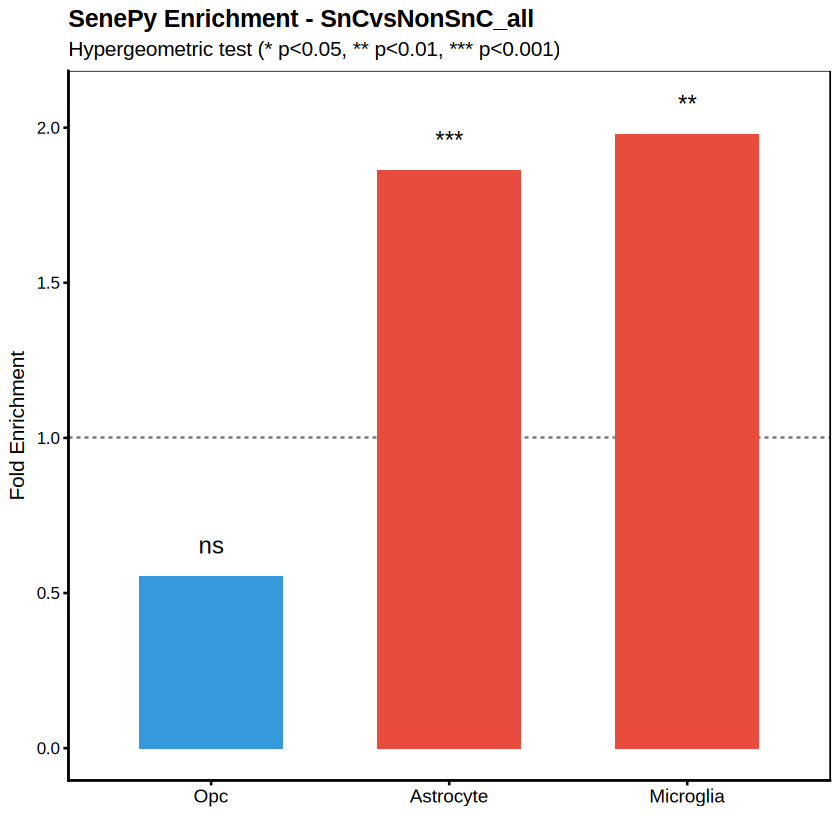

In [19]:
# ────────────────────────────────────────────────────────────────────────────────
# VISUALIZATION: HYPERGEOMETRIC ENRICHMENT BAR PLOT
# ────────────────────────────────────────────────────────────────────────────────

cat("\n--- Creating Enrichment Bar Plot ---\n")

# Build plot data
enrich_df <- do.call(rbind, lapply(names(overlap_results), function(ct) {
    r <- overlap_results[[ct]]
    data.frame(
        cell_type = tools::toTitleCase(ct),
        fold_enrichment = r$fold_enrichment,
        pval = r$hyper_pval,
        overlap = r$in_senespy
    )
}))

# Add significance labels
enrich_df$sig_label <- case_when(
    enrich_df$pval < 0.001 ~ "***",
    enrich_df$pval < 0.01 ~ "**",
    enrich_df$pval < 0.05 ~ "*",
    TRUE ~ "ns"
)

# Order by fold enrichment
enrich_df$cell_type <- factor(enrich_df$cell_type, 
                               levels = enrich_df$cell_type[order(enrich_df$fold_enrichment)])

p_enrich <- ggplot(enrich_df, aes(x = cell_type, y = fold_enrichment)) +
    geom_hline(yintercept = 1, linetype = "dashed", color = "grey50") +
    geom_col(aes(fill = fold_enrichment > 1), width = 0.6) +
    geom_text(aes(label = sig_label, y = fold_enrichment + 0.1), size = 5) +
    scale_fill_manual(values = c("TRUE" = "#E74C3C", "FALSE" = "#3498DB"), guide = "none") +
    labs(
        title = paste("SenePy Enrichment -", SENESPY_COMPARISON),
        subtitle = "Hypergeometric test (* p<0.05, ** p<0.01, *** p<0.001)",
        x = "",
        y = "Fold Enrichment"
    ) +
    theme_classic(base_size = 12) +
    theme(
        plot.title = element_text(face = "bold"),
        axis.text.x = element_text(size = 11),
        panel.border = element_rect(color = "black", fill = NA, linewidth = 0.5)
    )

p_enrich

enrich_file <- file.path(figures_base, "cross_celltype",
                         paste0(DATASET, "_senespy_enrichment_barplot.pdf"))
ggsave(enrich_file, p_enrich, width = 5, height = 4)
cat("✓ Saved:", basename(enrich_file), "\n")